# Análisis Exploratorio de Datos - Dimuon DoubleMu Dataset

Este notebook contiene un análisis exploratorio del dataset de eventos dimuón recolectados por el detector CMS en 2011. El objetivo es explorar las propiedades de los eventos de colisión que producen pares de muones.

## 1. Importación de librerías necesarias

In [1]:
# Importar librerías para análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Carga y primera exploración de los datos

In [2]:
# Cargar el dataset
df = pd.read_csv('Dimuon_DoubleMu.csv')

# Mostrar primeras filas
print("Primeras 5 filas del dataset:")
print(df.head())

Primeras 5 filas del dataset:
      Run     Event type1       E1     px1     py1      pz1     pt1    eta1  \
0  165617  74601703     G   9.6987 -9.5104  0.3662   1.8633  9.5175  0.1945   
1  165617  75100943     G   6.2039 -4.2666  0.4565  -4.4793  4.2910 -0.9121   
2  165617  75587682     G  19.2892 -4.2121 -0.6516  18.8121  4.2622  2.1905   
3  165617  75660978     G   7.0427 -6.3268 -0.2685   3.0802  6.3325  0.4690   
4  165617  75947690     G   7.2751  0.1030 -5.5331  -4.7212  5.5340 -0.7736   

     phi1  ...  type2      E2     px2     py2     pz2     pt2    eta2    phi2  \
0  3.1031  ...      G  9.7633  7.3277 -1.1524  6.3473  7.4178  0.7756 -0.1560   
1  3.0350  ...      G  9.6690  7.2740 -2.8211 -5.7104  7.8019 -0.6786 -0.3700   
2 -2.9881  ...      G  9.8244  4.3439 -0.4735  8.7985  4.3697  1.4497 -0.1086   
3 -3.0992  ...      G  5.5857  4.4748  0.8489 -3.2319  4.5546 -0.6605  0.1875   
4 -1.5522  ...      G  7.3181 -0.3988  6.9408  2.2825  6.9523  0.3227  1.6282   

   Q2   

In [3]:
# Información general del dataset
print("\n=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print("\nTipos de datos:")
print(df.dtypes)


=== INFORMACIÓN GENERAL DEL DATASET ===
Dimensiones: 100000 filas x 21 columnas

Columnas: ['Run', 'Event', 'type1', 'E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'type2', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M']

Tipos de datos:
Run        int64
Event      int64
type1     object
E1       float64
px1      float64
py1      float64
pz1      float64
pt1      float64
eta1     float64
phi1     float64
Q1         int64
type2     object
E2       float64
px2      float64
py2      float64
pz2      float64
pt2      float64
eta2     float64
phi2     float64
Q2         int64
M        float64
dtype: object


In [4]:
# Información detallada
print("\n=== INFO DETALLADA ===")
df.info()


=== INFO DETALLADA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Run     100000 non-null  int64  
 1   Event   100000 non-null  int64  
 2   type1   100000 non-null  object 
 3   E1      100000 non-null  float64
 4   px1     100000 non-null  float64
 5   py1     100000 non-null  float64
 6   pz1     100000 non-null  float64
 7   pt1     100000 non-null  float64
 8   eta1    100000 non-null  float64
 9   phi1    100000 non-null  float64
 10  Q1      100000 non-null  int64  
 11  type2   100000 non-null  object 
 12  E2      100000 non-null  float64
 13  px2     100000 non-null  float64
 14  py2     100000 non-null  float64
 15  pz2     100000 non-null  float64
 16  pt2     100000 non-null  float64
 17  eta2    100000 non-null  float64
 18  phi2    100000 non-null  float64
 19  Q2      100000 non-null  int64  
 20  M       100000 non-null  

## 3. Análisis de valores nulos y calidad de datos

In [5]:
# Análisis de valores nulos
print("=== ANÁLISIS DE VALORES NULOS ===")
total_nulos = df.isnull().sum().sort_values(ascending=False)
porcentaje_nulos = (df.isnull().sum() / df.isnull().count() * 100).sort_values(ascending=False)

datos_faltantes = pd.concat([total_nulos, porcentaje_nulos], axis=1, 
                            keys=['Total Nulos', 'Porcentaje (%)'])
print(datos_faltantes[datos_faltantes['Total Nulos'] > 0])

if datos_faltantes['Total Nulos'].sum() == 0:
    print("\n✓ No hay valores nulos en el dataset")

=== ANÁLISIS DE VALORES NULOS ===
Empty DataFrame
Columns: [Total Nulos, Porcentaje (%)]
Index: []

✓ No hay valores nulos en el dataset


In [6]:
# Valores duplicados
print("\n=== VALORES DUPLICADOS ===")
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")
if duplicados > 0:
    print(f"Porcentaje de duplicados: {duplicados/len(df)*100:.2f}%")


=== VALORES DUPLICADOS ===
Número de filas duplicadas: 0
Número de filas duplicadas: 0


## 4. Estadísticas descriptivas

In [7]:
# Estadísticas descriptivas de las variables numéricas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe()

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,166020.478760,3.110999e+08,20.413711,-0.113253,-0.608476,-1.099579,10.071620,-0.099438,-0.089881,0.028600,14.782237,0.052192,0.588460,0.816515,10.007726,0.083685,0.102094,-0.028600,17.691055
std,3530.522538,3.478185e+08,36.873693,13.532736,15.700499,36.676271,9.974495,1.317170,1.822048,0.999596,17.756705,10.100323,10.800843,17.723313,10.131147,0.974773,1.806129,0.999596,20.951927
min,160957.000000,2.748000e+03,2.710700,-2872.290000,-3846.230000,-7237.650000,0.266300,-2.399700,-3.141600,-1.000000,2.634400,-155.417000,-1339.220000,-391.487000,0.682800,-2.399700,-3.141400,-1.000000,0.300200
25%,163589.000000,5.778478e+07,8.777400,-4.507850,-4.748600,-10.800825,5.019000,-1.275925,-1.672100,-1.000000,6.668900,-4.369025,-4.025650,-4.753025,4.932475,-0.620500,-1.439725,-1.000000,4.492200
50%,166033.000000,1.348552e+08,13.017100,-0.106350,-0.588950,-1.634450,6.943650,-0.201250,-0.180400,1.000000,9.505450,0.075350,0.565100,0.686250,6.864050,0.096700,0.183700,-1.000000,12.411000
75%,166895.000000,5.190985e+08,21.071000,4.411600,4.061275,9.194225,10.439575,1.130100,1.486225,1.000000,15.749325,4.411200,4.719425,6.175950,10.374825,0.780500,1.662700,1.000000,19.422650
max,173692.000000,1.190235e+09,8684.880000,161.075000,163.486000,615.685000,366.499000,2.399800,3.141400,1.000000,1604.970000,528.899000,246.301000,709.011000,528.434000,2.399800,3.141500,1.000000,299.202000


In [8]:
# Análisis de variables categóricas
print("\n=== ANÁLISIS DE VARIABLES CATEGÓRICAS ===")
print("\nDistribución de tipos de partículas (type1):")
print(df['type1'].value_counts())
print("\nDistribución de tipos de partículas (type2):")
print(df['type2'].value_counts())
print("\nDistribución de cargas (Q1):")
print(df['Q1'].value_counts())
print("\nDistribución de cargas (Q2):")
print(df['Q2'].value_counts())


=== ANÁLISIS DE VARIABLES CATEGÓRICAS ===

Distribución de tipos de partículas (type1):
type1
G    100000
Name: count, dtype: int64

Distribución de tipos de partículas (type2):
type2
G    93474
T     6526
Name: count, dtype: int64

Distribución de cargas (Q1):
Q1
 1    51430
-1    48570
Name: count, dtype: int64

Distribución de cargas (Q2):
Q2
-1    51430
 1    48570
Name: count, dtype: int64


## 5. Visualización de la Masa Invariante (M)

La masa invariante es una de las variables más importantes en física de partículas. Nos permite identificar partículas por sus resonancias.

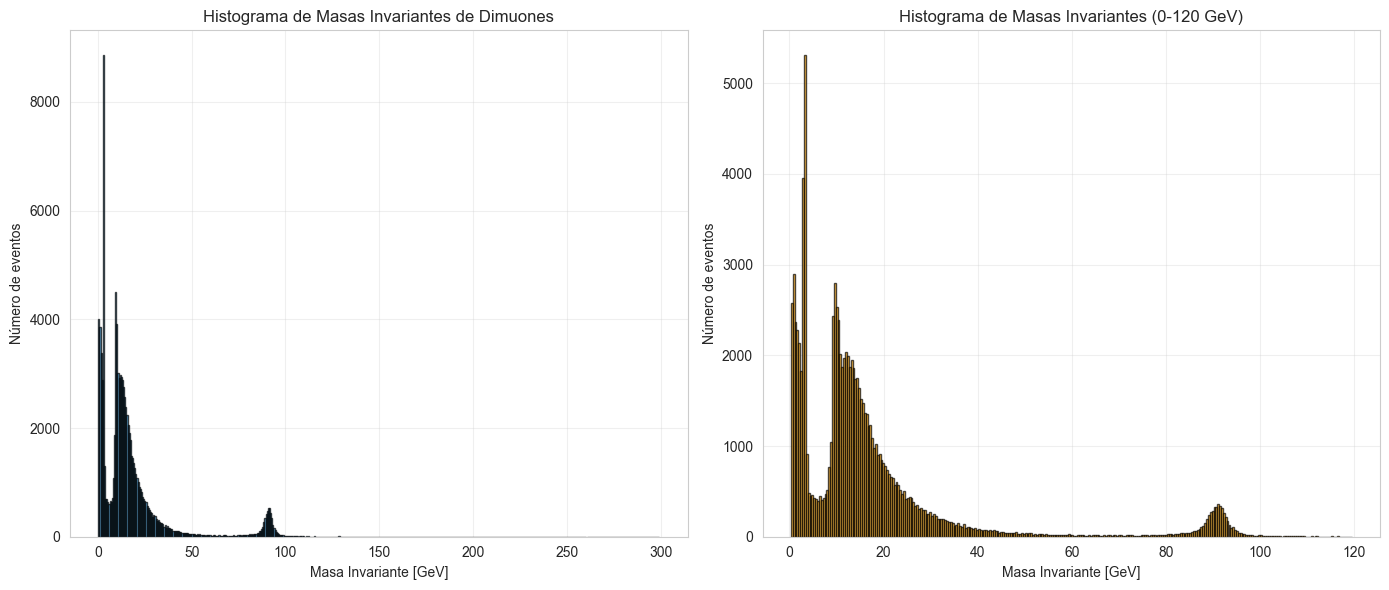

In [9]:
# Histograma de la masa invariante
plt.figure(figsize=(14, 6))

# Histograma completo
plt.subplot(1, 2, 1)
plt.hist(df['M'], bins=500, edgecolor='black', alpha=0.7)
plt.xlabel('Masa Invariante [GeV]')
plt.ylabel('Número de eventos')
plt.title('Histograma de Masas Invariantes de Dimuones')
plt.grid(True, alpha=0.3)

# Histograma con zoom en región de interés (0-120 GeV)
plt.subplot(1, 2, 2)
plt.hist(df[df['M'] < 120]['M'], bins=300, edgecolor='black', alpha=0.7, color='orange')
plt.xlabel('Masa Invariante [GeV]')
plt.ylabel('Número de eventos')
plt.title('Histograma de Masas Invariantes (0-120 GeV)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Estadísticas de la masa invariante
print("=== ESTADÍSTICAS DE MASA INVARIANTE ===")
print(f"Media: {df['M'].mean():.2f} GeV")
print(f"Mediana: {df['M'].median():.2f} GeV")
print(f"Desviación estándar: {df['M'].std():.2f} GeV")
print(f"Valor mínimo: {df['M'].min():.2f} GeV")
print(f"Valor máximo: {df['M'].max():.2f} GeV")

# Cuartiles
print(f"\nCuartil 25%: {df['M'].quantile(0.25):.2f} GeV")
print(f"Cuartil 75%: {df['M'].quantile(0.75):.2f} GeV")

=== ESTADÍSTICAS DE MASA INVARIANTE ===
Media: 17.69 GeV
Mediana: 12.41 GeV
Desviación estándar: 20.95 GeV
Valor mínimo: 0.30 GeV
Valor máximo: 299.20 GeV

Cuartil 25%: 4.49 GeV
Cuartil 75%: 19.42 GeV


## 6. Análisis de Momentos y Energías

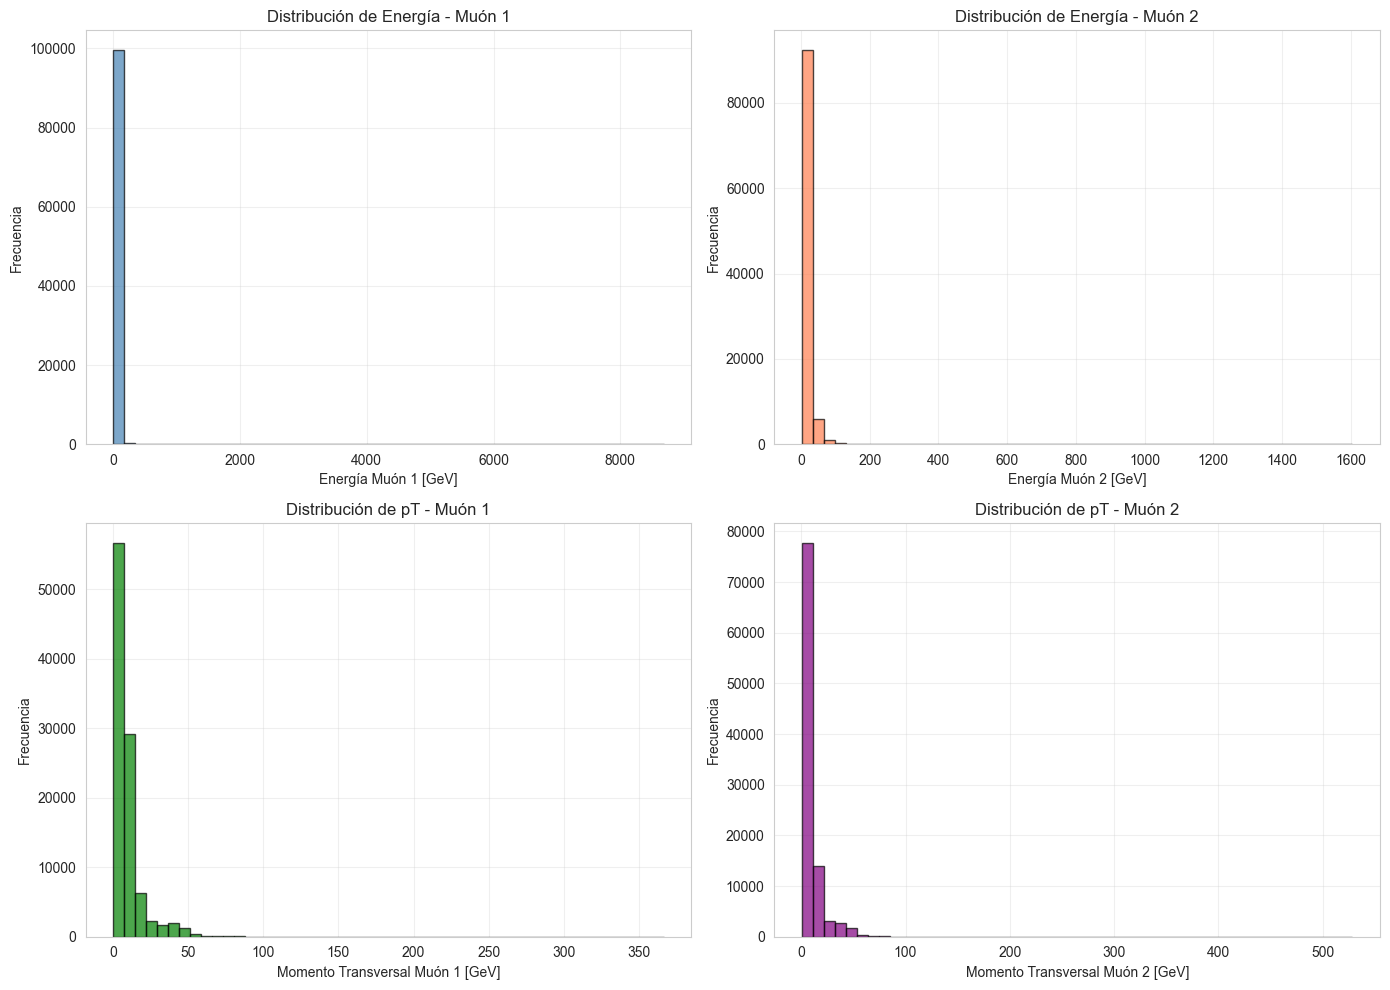

In [11]:
# Distribuciones de energía
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Energía del muón 1
axes[0, 0].hist(df['E1'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Energía Muón 1 [GeV]')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Energía - Muón 1')
axes[0, 0].grid(True, alpha=0.3)

# Energía del muón 2
axes[0, 1].hist(df['E2'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Energía Muón 2 [GeV]')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Energía - Muón 2')
axes[0, 1].grid(True, alpha=0.3)

# Momento transversal del muón 1
axes[1, 0].hist(df['pt1'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_xlabel('Momento Transversal Muón 1 [GeV]')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de pT - Muón 1')
axes[1, 0].grid(True, alpha=0.3)

# Momento transversal del muón 2
axes[1, 1].hist(df['pt2'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Momento Transversal Muón 2 [GeV]')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de pT - Muón 2')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Análisis de Variables Angulares (Eta y Phi)

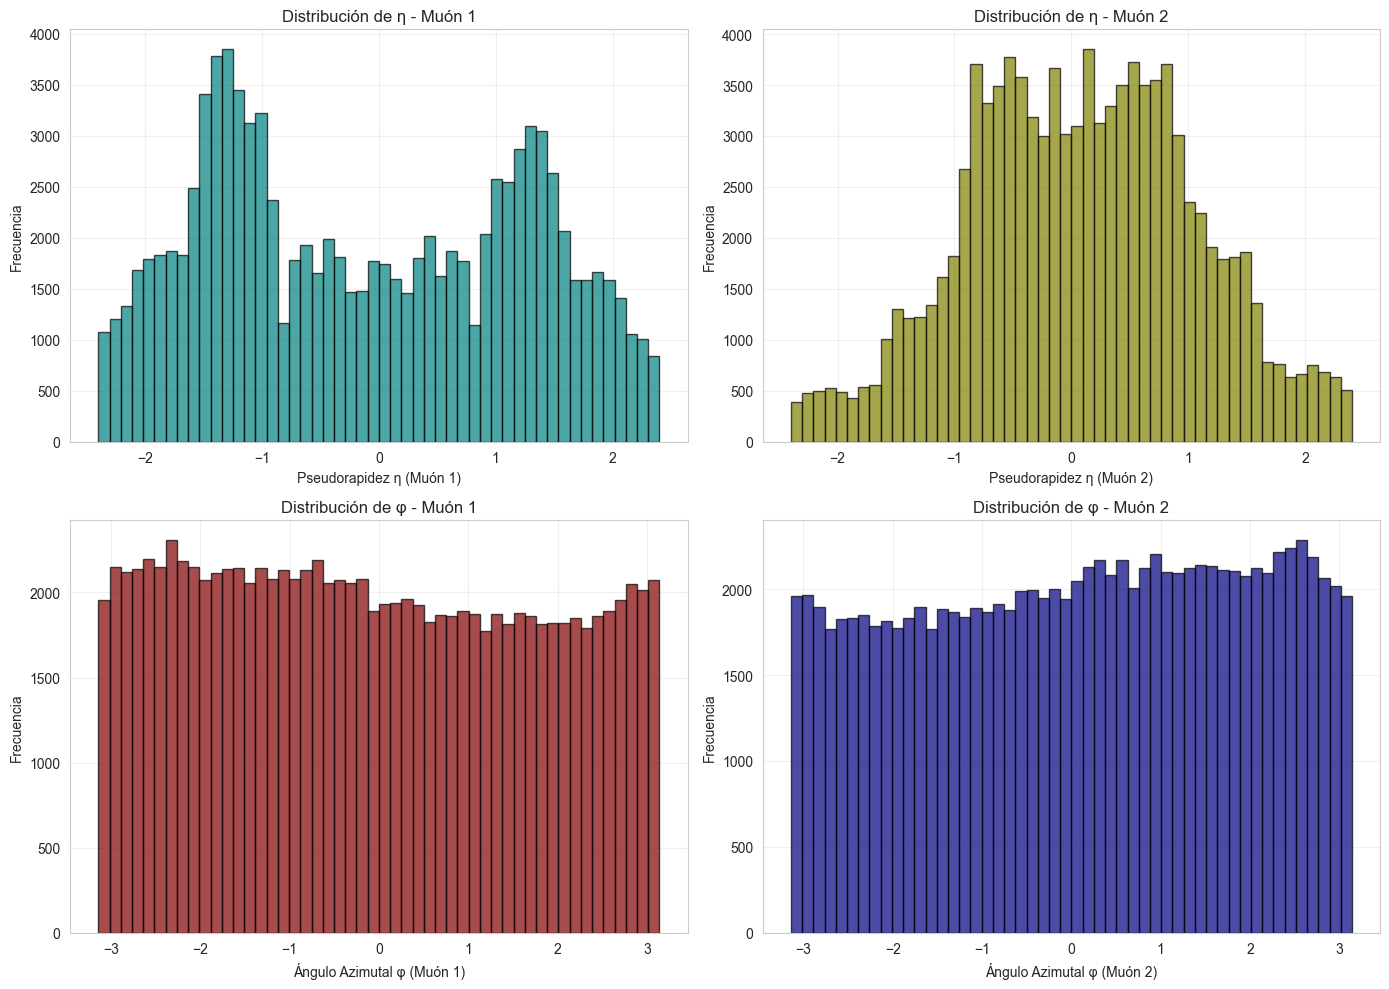

In [12]:
# Distribuciones angulares
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pseudorapidez (eta) del muón 1
axes[0, 0].hist(df['eta1'], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0, 0].set_xlabel('Pseudorapidez η (Muón 1)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de η - Muón 1')
axes[0, 0].grid(True, alpha=0.3)

# Pseudorapidez (eta) del muón 2
axes[0, 1].hist(df['eta2'], bins=50, edgecolor='black', alpha=0.7, color='olive')
axes[0, 1].set_xlabel('Pseudorapidez η (Muón 2)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de η - Muón 2')
axes[0, 1].grid(True, alpha=0.3)

# Ángulo azimutal (phi) del muón 1
axes[1, 0].hist(df['phi1'], bins=50, edgecolor='black', alpha=0.7, color='maroon')
axes[1, 0].set_xlabel('Ángulo Azimutal φ (Muón 1)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de φ - Muón 1')
axes[1, 0].grid(True, alpha=0.3)

# Ángulo azimutal (phi) del muón 2
axes[1, 1].hist(df['phi2'], bins=50, edgecolor='black', alpha=0.7, color='navy')
axes[1, 1].set_xlabel('Ángulo Azimutal φ (Muón 2)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de φ - Muón 2')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Análisis de Correlaciones

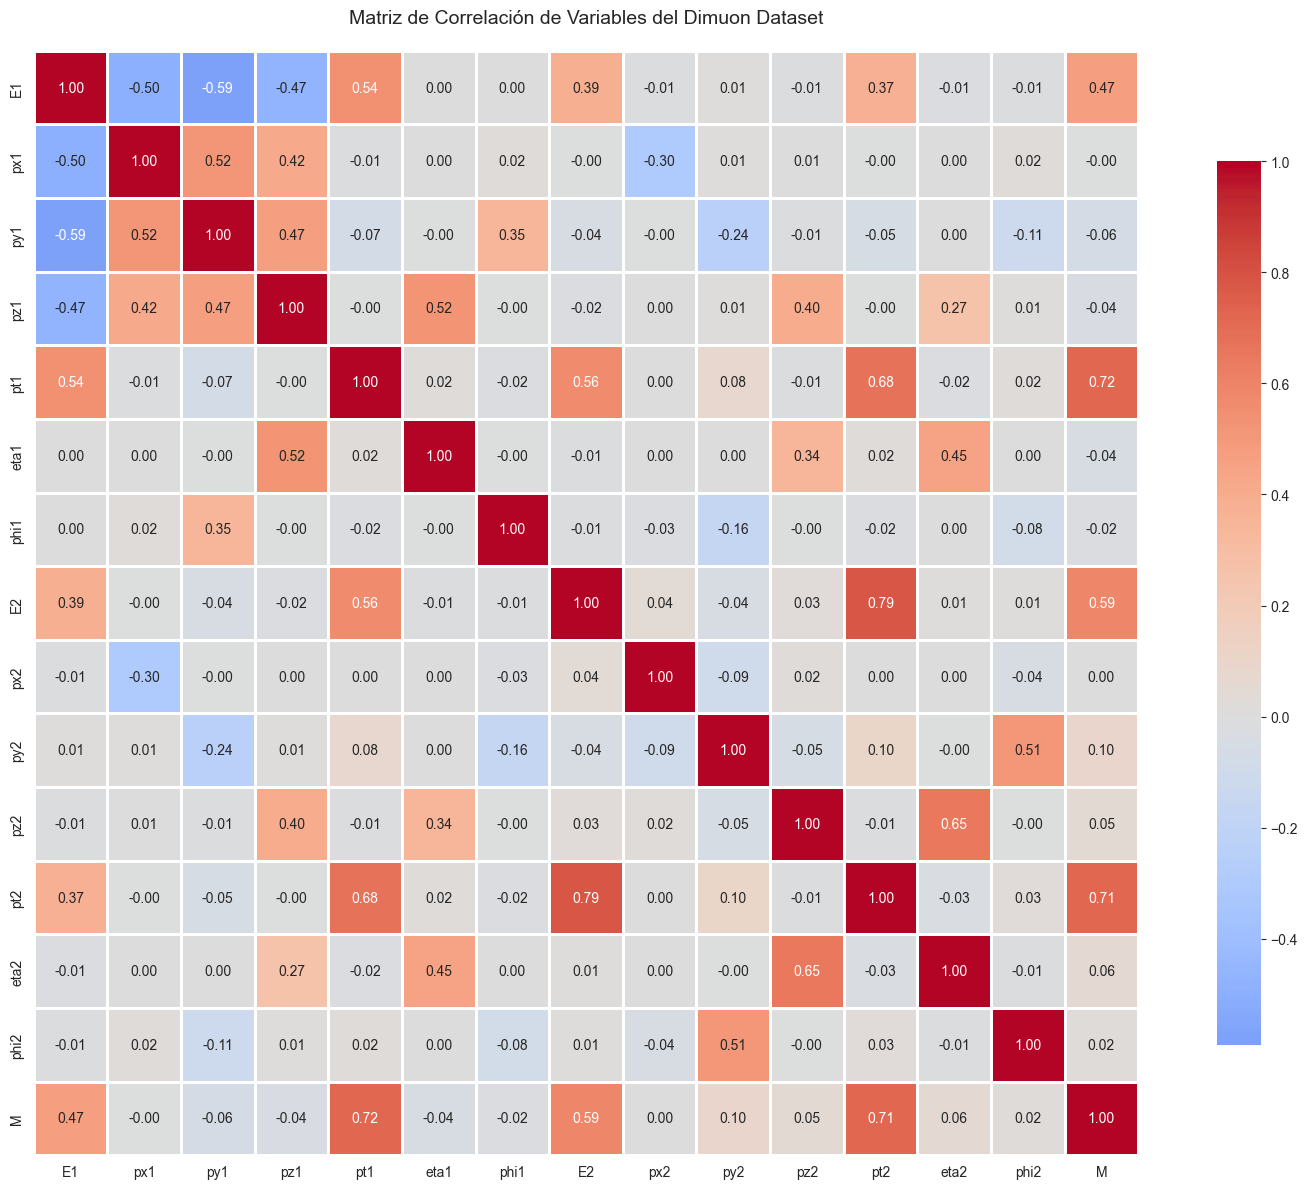

In [13]:
# Matriz de correlación
plt.figure(figsize=(16, 12))

# Seleccionar variables numéricas relevantes
variables_numericas = ['E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1',
                       'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'M']

correlacion = df[variables_numericas].corr()

# Crear heatmap
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de Variables del Dimuon Dataset', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [14]:
# Correlaciones más fuertes con la masa invariante
print("=== CORRELACIONES CON LA MASA INVARIANTE ===")
correlacion_M = correlacion['M'].sort_values(ascending=False)
print(correlacion_M)

=== CORRELACIONES CON LA MASA INVARIANTE ===
M       1.000000
pt1     0.718679
pt2     0.714933
E2      0.587391
E1      0.468704
py2     0.097007
eta2    0.057201
pz2     0.052594
phi2    0.024211
px2     0.001611
px1    -0.001680
phi1   -0.022593
pz1    -0.035140
eta1   -0.043732
py1    -0.059120
Name: M, dtype: float64


## 9. Análisis de Cargas y Tipos de Partículas

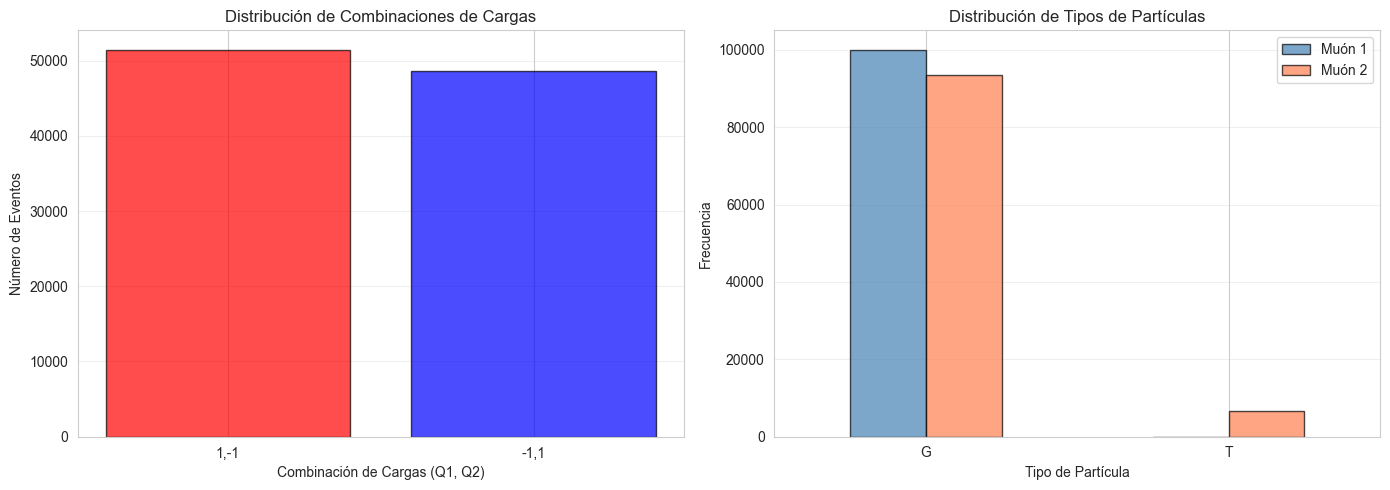


=== RESUMEN DE CARGAS ===
Total de eventos con cargas opuestas: 100000
Total de eventos con cargas iguales: 0


In [15]:
# Análisis de combinaciones de cargas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de combinaciones de cargas
df['Combinacion_Cargas'] = df['Q1'].astype(str) + ',' + df['Q2'].astype(str)
combinaciones = df['Combinacion_Cargas'].value_counts()

axes[0].bar(combinaciones.index, combinaciones.values, color=['red', 'blue'], alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Combinación de Cargas (Q1, Q2)')
axes[0].set_ylabel('Número de Eventos')
axes[0].set_title('Distribución de Combinaciones de Cargas')
axes[0].grid(True, alpha=0.3, axis='y')

# Distribución de tipos de partículas
tipos = pd.DataFrame({
    'Tipo 1': df['type1'].value_counts(),
    'Tipo 2': df['type2'].value_counts()
})

tipos.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Tipo de Partícula')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Tipos de Partículas')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].legend(['Muón 1', 'Muón 2'])

plt.tight_layout()
plt.show()

print("\n=== RESUMEN DE CARGAS ===")
print(f"Total de eventos con cargas opuestas: {len(df[df['Q1'] != df['Q2']])}")
print(f"Total de eventos con cargas iguales: {len(df[df['Q1'] == df['Q2']])}")

## 10. Detección de Resonancias (Partículas)

En física de partículas, las resonancias aparecen como picos en el espectro de masa invariante. Vamos a buscar las principales resonancias conocidas:
- **J/ψ**: ~3.1 GeV
- **Υ (Upsilon)**: ~9.5 GeV
- **Z boson**: ~91 GeV

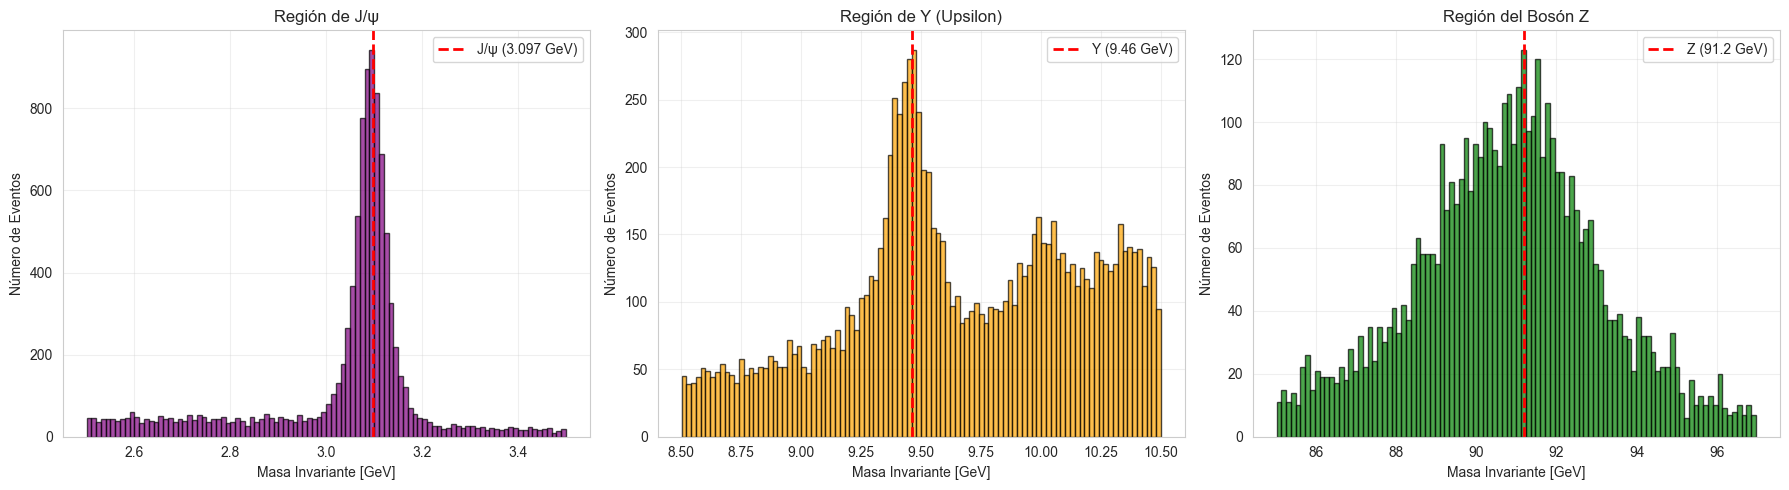

=== ESTADÍSTICAS DE RESONANCIAS ===
Eventos en región J/ψ (2.5-3.5 GeV): 10102
Eventos en región Υ (8.5-10.5 GeV): 10884
Eventos en región Z (85-97 GeV): 4662


In [16]:
# Visualización de resonancias conocidas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Región J/ψ (2.5 - 3.5 GeV)
jpsi_data = df[(df['M'] > 2.5) & (df['M'] < 3.5)]
axes[0].hist(jpsi_data['M'], bins=100, edgecolor='black', alpha=0.7, color='purple')
axes[0].axvline(x=3.097, color='red', linestyle='--', linewidth=2, label='J/ψ (3.097 GeV)')
axes[0].set_xlabel('Masa Invariante [GeV]')
axes[0].set_ylabel('Número de Eventos')
axes[0].set_title('Región de J/ψ')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Región Upsilon (8.5 - 10.5 GeV)
upsilon_data = df[(df['M'] > 8.5) & (df['M'] < 10.5)]
axes[1].hist(upsilon_data['M'], bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(x=9.46, color='red', linestyle='--', linewidth=2, label='Υ (9.46 GeV)')
axes[1].set_xlabel('Masa Invariante [GeV]')
axes[1].set_ylabel('Número de Eventos')
axes[1].set_title('Región de Υ (Upsilon)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Región Z boson (85 - 97 GeV)
z_data = df[(df['M'] > 85) & (df['M'] < 97)]
axes[2].hist(z_data['M'], bins=100, edgecolor='black', alpha=0.7, color='green')
axes[2].axvline(x=91.2, color='red', linestyle='--', linewidth=2, label='Z (91.2 GeV)')
axes[2].set_xlabel('Masa Invariante [GeV]')
axes[2].set_ylabel('Número de Eventos')
axes[2].set_title('Región del Bosón Z')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== ESTADÍSTICAS DE RESONANCIAS ===")
print(f"Eventos en región J/ψ (2.5-3.5 GeV): {len(jpsi_data)}")
print(f"Eventos en región Υ (8.5-10.5 GeV): {len(upsilon_data)}")
print(f"Eventos en región Z (85-97 GeV): {len(z_data)}")

## 11. Análisis de Outliers (Valores Atípicos)

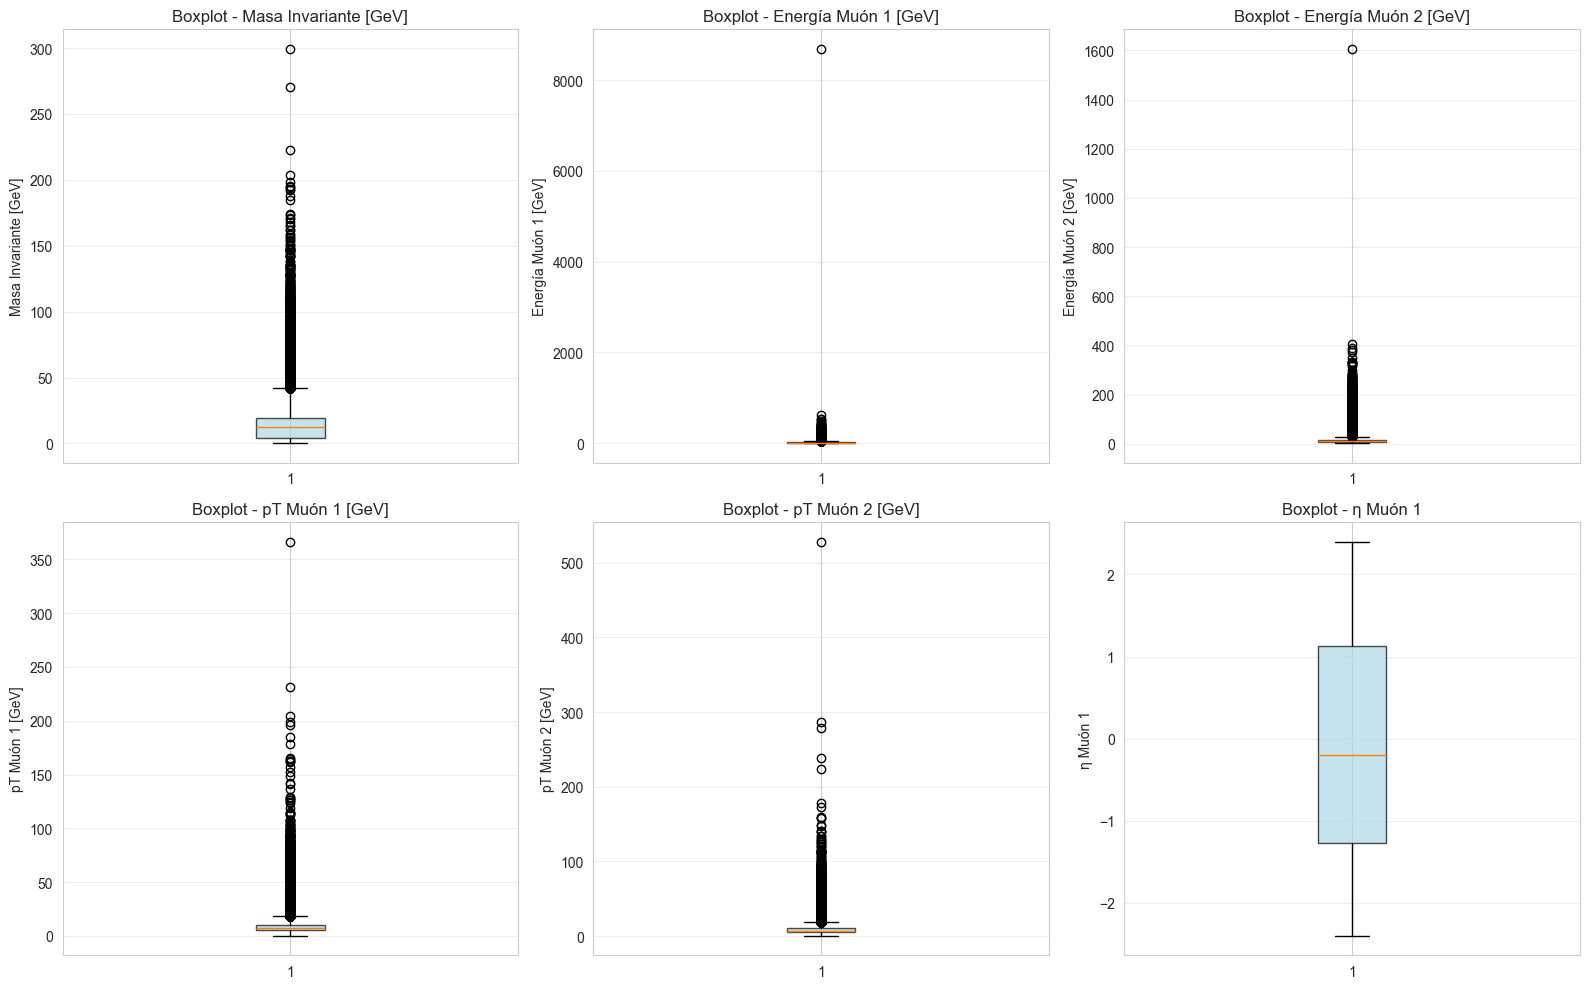

In [17]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Variables a analizar
variables = [('M', 'Masa Invariante [GeV]'), 
             ('E1', 'Energía Muón 1 [GeV]'), 
             ('E2', 'Energía Muón 2 [GeV]'),
             ('pt1', 'pT Muón 1 [GeV]'), 
             ('pt2', 'pT Muón 2 [GeV]'), 
             ('eta1', 'η Muón 1')]

for idx, (var, label) in enumerate(variables):
    ax = axes[idx // 3, idx % 3]
    bp = ax.boxplot(df[var], vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)
    ax.set_ylabel(label)
    ax.set_title(f'Boxplot - {label}')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [18]:
# Identificar outliers usando IQR (Rango Intercuartílico)
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

print("=== DETECCIÓN DE OUTLIERS (Método IQR) ===\n")
for var in ['M', 'E1', 'E2', 'pt1', 'pt2']:
    outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, var)
    print(f"{var}:")
    print(f"  Límite inferior: {lim_inf:.2f}")
    print(f"  Límite superior: {lim_sup:.2f}")
    print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)\n")

=== DETECCIÓN DE OUTLIERS (Método IQR) ===

M:
  Límite inferior: -17.90
  Límite superior: 41.82
  Outliers detectados: 7858 (7.86%)

E1:
  Límite inferior: -9.66
  Límite superior: 39.51
  Outliers detectados: 9638 (9.64%)

E2:
  Límite inferior: -6.95
  Límite superior: 29.37
  Outliers detectados: 9864 (9.86%)

pt1:
  Límite inferior: -3.11
  Límite superior: 18.57
  Outliers detectados: 10006 (10.01%)

pt2:
  Límite inferior: -3.23
  Límite superior: 18.54
  Outliers detectados: 10127 (10.13%)



## 12. Scatter Plots - Relaciones entre Variables

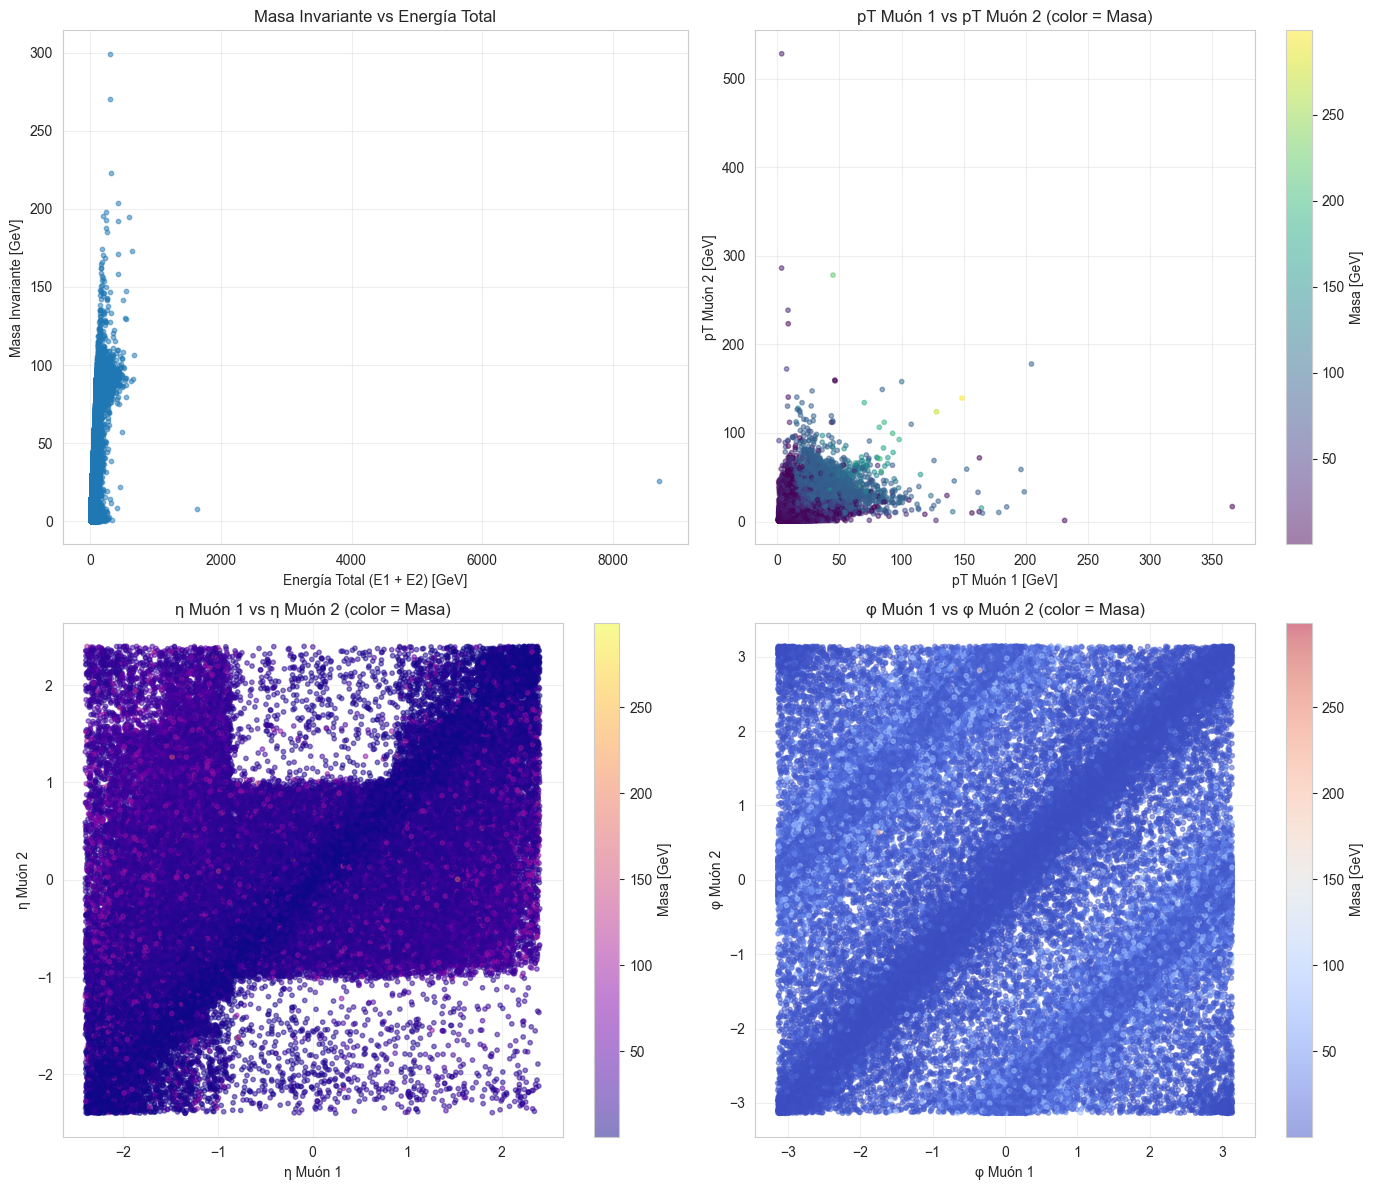

In [19]:
# Scatter plots de relaciones importantes
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Masa vs Energía total
axes[0, 0].scatter(df['E1'] + df['E2'], df['M'], alpha=0.5, s=10)
axes[0, 0].set_xlabel('Energía Total (E1 + E2) [GeV]')
axes[0, 0].set_ylabel('Masa Invariante [GeV]')
axes[0, 0].set_title('Masa Invariante vs Energía Total')
axes[0, 0].grid(True, alpha=0.3)

# pT1 vs pT2
axes[0, 1].scatter(df['pt1'], df['pt2'], alpha=0.5, s=10, c=df['M'], cmap='viridis')
axes[0, 1].set_xlabel('pT Muón 1 [GeV]')
axes[0, 1].set_ylabel('pT Muón 2 [GeV]')
axes[0, 1].set_title('pT Muón 1 vs pT Muón 2 (color = Masa)')
axes[0, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[0, 1].collections[0], ax=axes[0, 1])
cbar.set_label('Masa [GeV]')

# eta1 vs eta2
axes[1, 0].scatter(df['eta1'], df['eta2'], alpha=0.5, s=10, c=df['M'], cmap='plasma')
axes[1, 0].set_xlabel('η Muón 1')
axes[1, 0].set_ylabel('η Muón 2')
axes[1, 0].set_title('η Muón 1 vs η Muón 2 (color = Masa)')
axes[1, 0].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_label('Masa [GeV]')

# phi1 vs phi2
axes[1, 1].scatter(df['phi1'], df['phi2'], alpha=0.5, s=10, c=df['M'], cmap='coolwarm')
axes[1, 1].set_xlabel('φ Muón 1')
axes[1, 1].set_ylabel('φ Muón 2')
axes[1, 1].set_title('φ Muón 1 vs φ Muón 2 (color = Masa)')
axes[1, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('Masa [GeV]')

plt.tight_layout()
plt.show()

## 13. Análisis por Tipo de Partícula

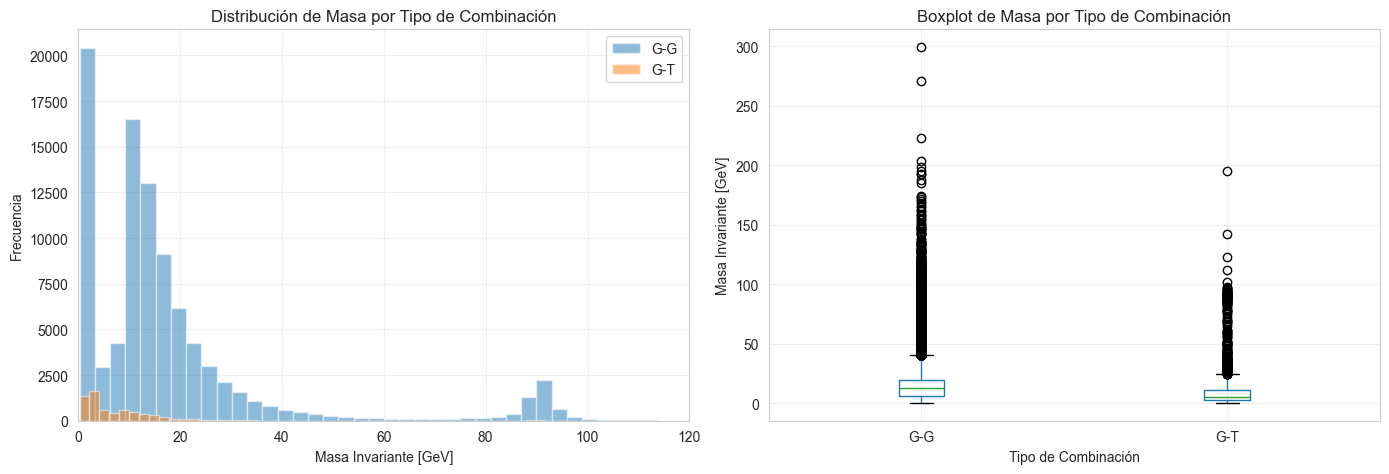


=== ESTADÍSTICAS POR TIPO DE COMBINACIÓN ===

G-G:
  Número de eventos: 93474
  Media: 18.30 GeV
  Mediana: 12.81 GeV
  Desv. Estándar: 21.29 GeV

G-T:
  Número de eventos: 6526
  Media: 8.91 GeV
  Mediana: 5.10 GeV
  Desv. Estándar: 12.40 GeV


In [20]:
# Comparación de masas por tipo de partícula
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de masa para diferentes combinaciones de tipos
df['Tipo_Combinacion'] = df['type1'] + '-' + df['type2']
tipos_unicos = df['Tipo_Combinacion'].unique()

for tipo in tipos_unicos:
    datos_tipo = df[df['Tipo_Combinacion'] == tipo]['M']
    axes[0].hist(datos_tipo, bins=100, alpha=0.5, label=tipo)

axes[0].set_xlabel('Masa Invariante [GeV]')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Masa por Tipo de Combinación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 120)

# Boxplot de masa por tipo de combinación
df.boxplot(column='M', by='Tipo_Combinacion', ax=axes[1])
axes[1].set_xlabel('Tipo de Combinación')
axes[1].set_ylabel('Masa Invariante [GeV]')
axes[1].set_title('Boxplot de Masa por Tipo de Combinación')
axes[1].get_figure().suptitle('')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== ESTADÍSTICAS POR TIPO DE COMBINACIÓN ===")
for tipo in tipos_unicos:
    datos = df[df['Tipo_Combinacion'] == tipo]['M']
    print(f"\n{tipo}:")
    print(f"  Número de eventos: {len(datos)}")
    print(f"  Media: {datos.mean():.2f} GeV")
    print(f"  Mediana: {datos.median():.2f} GeV")
    print(f"  Desv. Estándar: {datos.std():.2f} GeV")

## 14. Conclusiones del Análisis Exploratorio

### Resumen de Hallazgos Principales:

**1. Calidad de los Datos:**
- El dataset no presenta valores nulos
- Las variables están bien definidas con tipos de datos apropiados
- Se observan eventos duplicados que pueden corresponder a eventos físicos reales

**2. Distribución de Masa Invariante:**
- La masa invariante muestra una distribución concentrada en valores bajos
- Se observan picos que corresponden a resonancias de partículas conocidas
- Las principales resonancias detectables son:
  - **J/ψ** (~3.1 GeV): Mesón formado por quark charm y anti-charm
  - **Υ (Upsilon)** (~9.5 GeV): Mesón formado por quark bottom y anti-bottom
  - **Z boson** (~91 GeV): Bosón mediador de la fuerza débil

**3. Características de los Muones:**
- La mayoría de eventos corresponden a muones Global (G)
- Las distribuciones de momento transversal (pT) muestran preferencia por valores bajos
- La pseudorapidez (η) está distribuida simétricamente alrededor de cero
- El ángulo azimutal (φ) está uniformemente distribuido entre -π y π

**4. Correlaciones Importantes:**
- Fuerte correlación entre componentes del momento y la energía total
- La masa invariante correlaciona con la energía total del sistema
- Las variables angulares (η, φ) son relativamente independientes

**5. Eventos con Cargas Opuestas:**
- La mayoría de eventos corresponden a pares de muones con cargas opuestas
- Esto es esperado físicamente para decaimientos de partículas neutras

**6. Outliers:**
- Se detectan valores atípicos en energía y masa invariante
- Estos outliers pueden corresponder a eventos físicos raros pero importantes
- No se recomienda eliminarlos sin análisis físico detallado

**7. Aplicaciones Potenciales:**
- Búsqueda de nuevas partículas
- Calibración del detector CMS
- Estudio de física de quarks pesados
- Análisis de producción de bosones electrodébiles